In [70]:
# toying with basic graident boosting

In [71]:
import numpy as np
import matplotlib.pyplot as plt

In [72]:
np.random.seed(42)

In [73]:
X = np.random.rand(100) - 0.5
X.shape

(100,)

In [74]:
y = 3 * X ** 2 + 0.05 * np.random.randn(100)
y.shape

(100,)

In [75]:
import pandas as pd

In [76]:
df = pd.DataFrame()

In [77]:
df['X'] = X

In [78]:
df['y'] = y

In [79]:
df.head()

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986


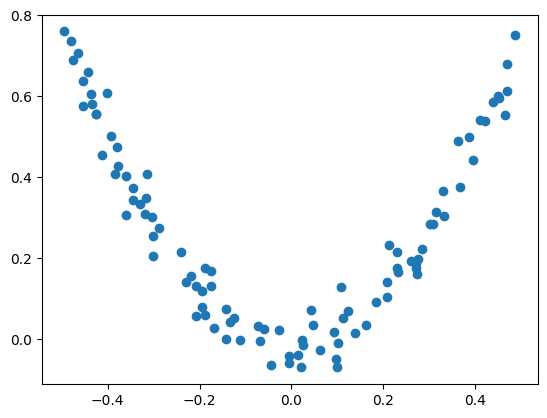

In [80]:
plt.scatter(df['X'], df['y'])

In [81]:
# now applyinh gradient boosting with model 1

In [82]:
df['pred1'] = df['y'].mean()

In [83]:
df.head()

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


In [84]:
df['res1'] = df['y'] - df['pred1']

In [85]:
df.head()

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


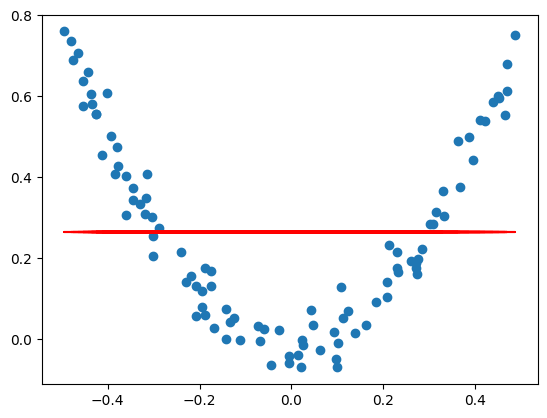

In [87]:
plt.scatter(df['X'], df['y'])
plt.plot(df['X'], df['pred1'], color = 'red')

In [86]:
# now training a new decsion tree model with X as input and res1 as output

In [92]:
from sklearn.tree import DecisionTreeRegressor

In [93]:
dt1 = DecisionTreeRegressor(max_leaf_nodes= 8)

In [94]:
dt1.fit(df['X'].values.reshape(-1, 1), df['res1'])

DecisionTreeRegressor(max_leaf_nodes=8)

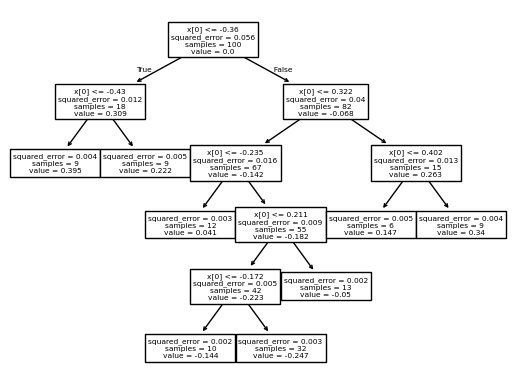

In [95]:
from sklearn.tree import plot_tree
plot_tree(dt1)
plt.show()

In [103]:
df['pred2'] = df['pred1'] + 0.5 * dt1.predict(df['X'].values.reshape(-1, 1))

In [104]:
df['res2'] = df['y'] - df['pred2']

In [105]:
df.head()

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.141889,-0.090316
1,0.450714,0.594480,0.265458,0.329021,0.435671,0.158809
2,0.231994,0.166052,0.265458,-0.099407,0.240621,-0.074570
3,0.098658,-0.070178,0.265458,-0.335636,0.141889,-0.212067
4,-0.343981,0.343986,0.265458,0.078528,0.285712,0.058274


In [110]:
dt2 = DecisionTreeRegressor(max_leaf_nodes= 8)

In [111]:
dt2.fit(df['X'].values.reshape(-1, 1), df['res2'])

DecisionTreeRegressor(max_leaf_nodes=8)

In [112]:
df['pred3'] = df['pred1'] + 0.5 * dt1.predict(df['X'].values.reshape(-1, 1)) + 0.5 * dt2.predict(df['X'].values.reshape(-1, 1))

In [113]:
df.head()

,X,y,pred1,res1,pred2,res2,pred3
0,-0.125460,0.051573,0.265458,-0.213885,0.141889,-0.090316,0.104272
1,0.450714,0.594480,0.265458,0.329021,0.435671,0.158809,0.500381
2,0.231994,0.166052,0.265458,-0.099407,0.240621,-0.074570,0.228989
3,0.098658,-0.070178,0.265458,-0.335636,0.141889,-0.212067,0.072068
4,-0.343981,0.343986,0.265458,0.078528,0.285712,0.058274,0.312527


In [114]:
df['res3'] = df['y'] - df['pred3']

In [115]:
df.head()

,X,y,pred1,res1,pred2,res2,pred3,res3
0,-0.125460,0.051573,0.265458,-0.213885,0.141889,-0.090316,0.104272,-0.052699
1,0.450714,0.594480,0.265458,0.329021,0.435671,0.158809,0.500381,0.094098
2,0.231994,0.166052,0.265458,-0.099407,0.240621,-0.074570,0.228989,-0.062937
3,0.098658,-0.070178,0.265458,-0.335636,0.141889,-0.212067,0.072068,-0.142246
4,-0.343981,0.343986,0.265458,0.078528,0.285712,0.058274,0.312527,0.031459


In [120]:
dt3 = DecisionTreeRegressor(max_leaf_nodes= 8)

In [121]:
dt3.fit(df['X'].values.reshape(-1, 1), df['res3'])

DecisionTreeRegressor(max_leaf_nodes=8)

In [122]:
df['pred4'] = df['pred3'] + 0.5 * dt3.predict(df['X'].values.reshape(-1, 1))

In [123]:
df.head()

,X,y,pred1,res1,pred2,res2,pred3,res3,pred4
0,-0.125460,0.051573,0.265458,-0.213885,0.141889,-0.090316,0.104272,-0.052699,0.063804
1,0.450714,0.594480,0.265458,0.329021,0.435671,0.158809,0.500381,0.094098,0.552039
2,0.231994,0.166052,0.265458,-0.099407,0.240621,-0.074570,0.228989,-0.062937,0.215701
3,0.098658,-0.070178,0.265458,-0.335636,0.141889,-0.212067,0.072068,-0.142246,0.031600
4,-0.343981,0.343986,0.265458,0.078528,0.285712,0.058274,0.312527,0.031459,0.328466


In [124]:
df['res4'] = df['y'] - df['pred4']

In [125]:
df.head()

,X,y,pred1,res1,pred2,res2,pred3,res3,pred4,res4
0,-0.125460,0.051573,0.265458,-0.213885,0.141889,-0.090316,0.104272,-0.052699,0.063804,-0.012231
1,0.450714,0.594480,0.265458,0.329021,0.435671,0.158809,0.500381,0.094098,0.552039,0.042440
2,0.231994,0.166052,0.265458,-0.099407,0.240621,-0.074570,0.228989,-0.062937,0.215701,-0.049650
3,0.098658,-0.070178,0.265458,-0.335636,0.141889,-0.212067,0.072068,-0.142246,0.031600,-0.101778
4,-0.343981,0.343986,0.265458,0.078528,0.285712,0.058274,0.312527,0.031459,0.328466,0.015519


In [127]:
df[['res1', 'res2', 'res3', 'res4']].head()

,res1,res2,res3,res4
0,-0.213885,-0.090316,-0.052699,-0.012231
1,0.329021,0.158809,0.094098,0.042440
2,-0.099407,-0.074570,-0.062937,-0.049650
3,-0.335636,-0.212067,-0.142246,-0.101778
4,0.078528,0.058274,0.031459,0.015519
